In [40]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import argrelextrema

# Part A - Discrete Chaotic Systems

A.2 Logistic map: xn+1 = r * xn * (1 - xn)


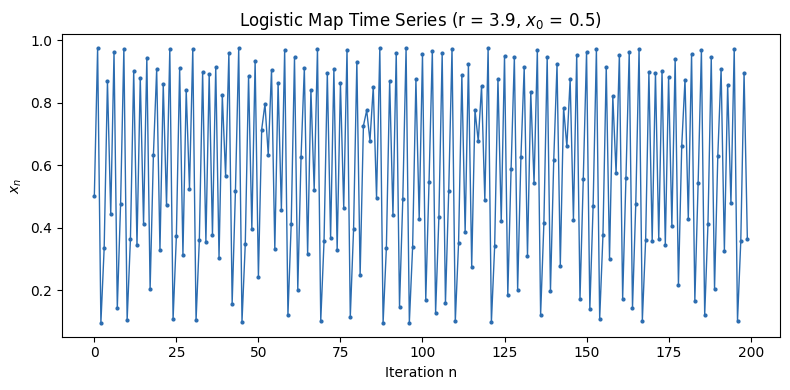

In [45]:
# Function that calculates the next value in the logistic map

def logistic_timeseries(r=3.9, x0=0.5, n_iter=200):
    x = np.zeros(n_iter)

    # Set the first value
    x[0] = x0

    for n in range(n_iter - 1):
        # Calculate the next value using the logistic equation
        x[n+1] = r * x[n] * (1 - x[n])
    return x

# Generate 200 values using r = 3.9
# r -> Growth rate, x0 -> Starting value, n_iter ->  Number of iterations
x_ts = logistic_timeseries(r=3.9, x0=0.5, n_iter=200)

plt.figure(figsize=(8, 4))
plt.plot(x_ts, lw=1, color="#2b6cb0", marker='o', markersize=2)

plt.xlabel("Iteration n")
plt.ylabel(r"$x_n$")
plt.title("Logistic Map Time Series (r = 3.9, $x_0$ = 0.5)")

plt.tight_layout()
plt.show()




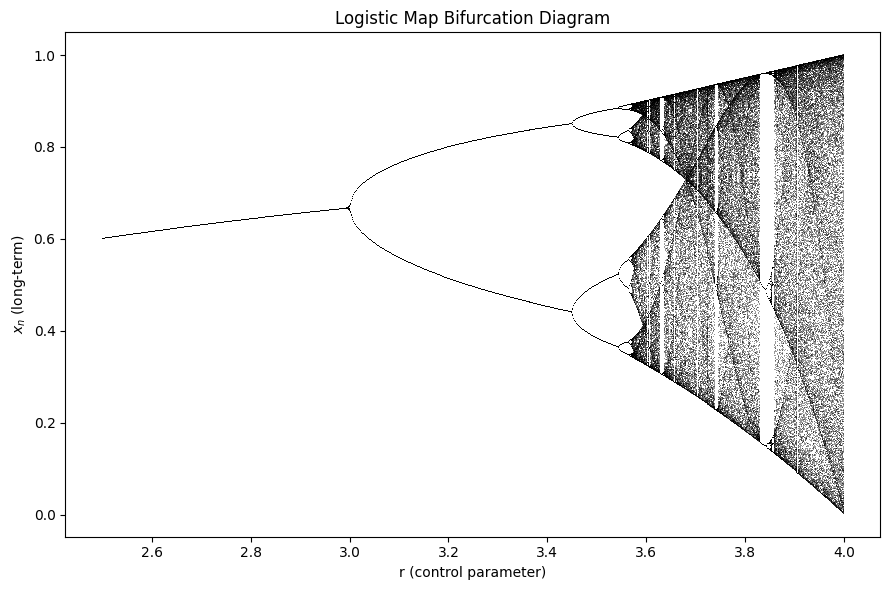

In [15]:
# Function that changes the growth rate (r) little by little
# and records the long-term behavior of the Logistic Map.

def logistic_bifurcation(r_min=2.5, r_max=4.0, r_step=0.002,
                          n_iter=1000, n_transient=500, x0=0.5):

    # Create all r values from 2.5 to 4.0.
    r_vals = np.arange(r_min, r_max, r_step)
    R, X = [], []

    #Test every r value
    for r in r_vals:
        x = x0
        # Ignore the first iterations because the system has not reached its long-term behavior yet
        for _ in range(n_transient):
            x = r * x * (1 - x)

        # Store only the remaining values
        for _ in range(n_iter - n_transient):
            x = r * x * (1 - x)
            R.append(r)
            X.append(x)
    return np.array(R), np.array(X)

R, X = logistic_bifurcation()

plt.figure(figsize=(9, 6))
plt.plot(R, X, ',k', alpha=0.4, markersize=0.5)

plt.xlabel("r (control parameter)")
plt.ylabel(r"$x_n$ (long-term)")
plt.title("Logistic Map Bifurcation Diagram")

plt.tight_layout()
plt.show()


 A.3 Henon map: xn+1 = 1 - a*xn^2 + yn ; yn+1 = b*xn


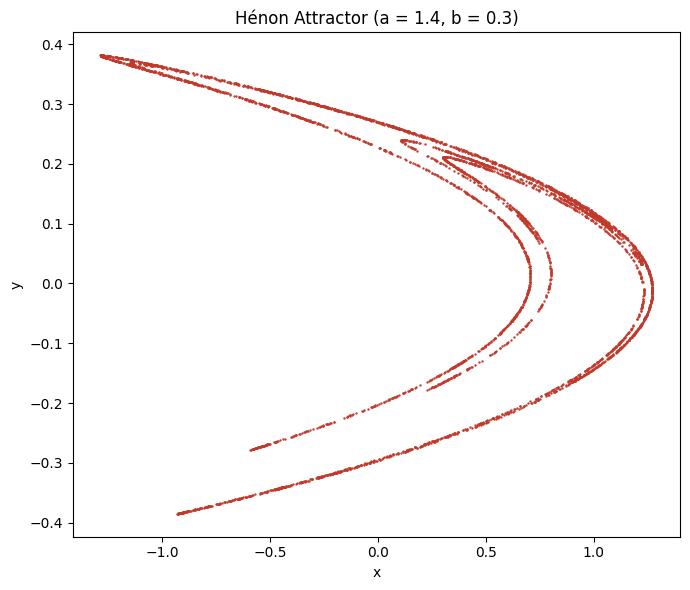

In [17]:
def henon_iterate(a=1.4, b=0.3, x0=0.0, y0=0.0, n_iter=5000, n_transient=500):
    x, y = x0, y0
    xs, ys = [], []
    for i in range(n_iter):
        x_new = 1 - a * x**2 + y
        y_new = b * x
        x, y = x_new, y_new
        if i >= n_transient:
            xs.append(x)
            ys.append(y)
    return np.array(xs), np.array(ys)

hx, hy = henon_iterate()

plt.figure(figsize=(7, 6))
plt.scatter(hx, hy, s=0.5, color="#c0392b")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Hénon Attractor (a = 1.4, b = 0.3)")

plt.tight_layout()
plt.show()

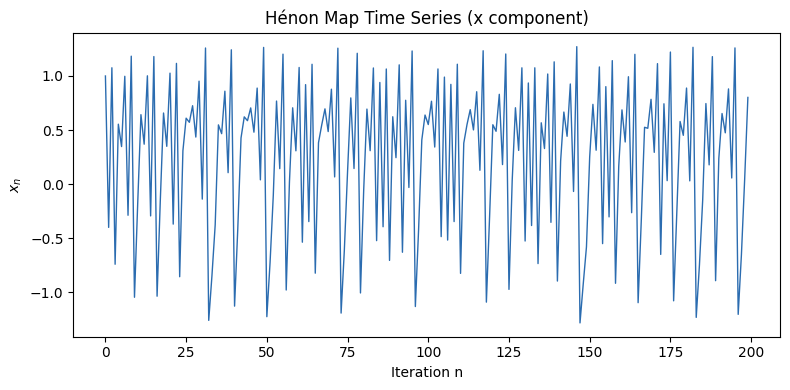

In [18]:
# Henon time series (x component) for completeness
hx_full, hy_full = henon_iterate(n_iter=200, n_transient=0)
plt.figure(figsize=(8, 4))
plt.plot(hx_full, lw=1, color="#2b6cb0")
plt.xlabel("Iteration n")
plt.ylabel(r"$x_n$")
plt.title("Hénon Map Time Series (x component)")
plt.tight_layout()
plt.show()


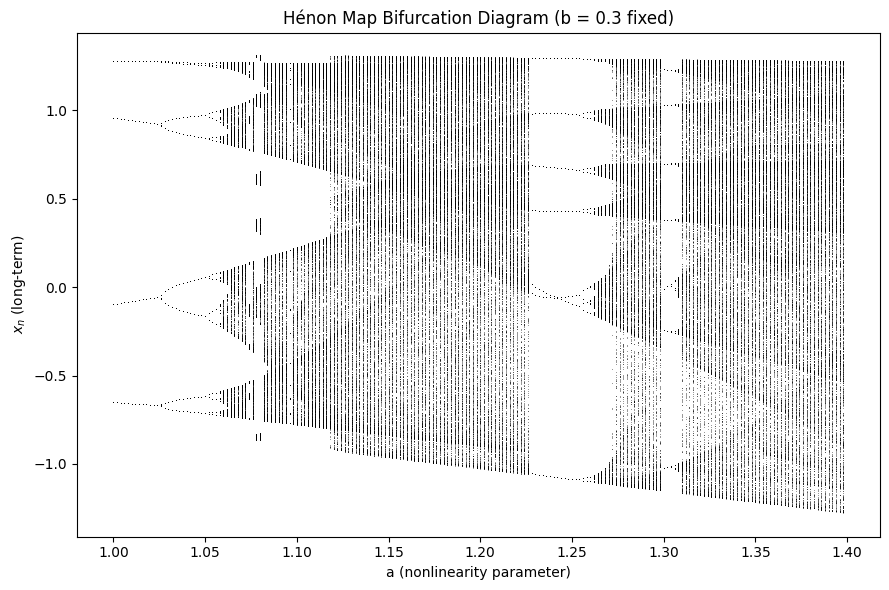

In [19]:
# Henon bifurcation diagram: sweep a, b fixed = 0.3
def henon_bifurcation(a_min=1.0, a_max=1.4, a_step=0.002,
                       b=0.3, n_iter=2000, n_transient=500, x0=0.0, y0=0.0):
    a_vals = np.arange(a_min, a_max, a_step)
    A, X = [], []
    for a in a_vals:
        x, y = x0, y0
        for _ in range(n_transient):
            x, y = 1 - a * x**2 + y, b * x
        for _ in range(n_iter - n_transient):
            x, y = 1 - a * x**2 + y, b * x
            A.append(a)
            X.append(x)
    return np.array(A), np.array(X)

Ah, Xh = henon_bifurcation()
plt.figure(figsize=(9, 6))
plt.plot(Ah, Xh, ',k', alpha=0.4, markersize=0.5)
plt.xlabel("a (nonlinearity parameter)")
plt.ylabel(r"$x_n$ (long-term)")
plt.title("Hénon Map Bifurcation Diagram (b = 0.3 fixed)")
plt.tight_layout()
plt.show()

# Part B - Continuous Chaotic/Hyperchaotic Systems  



In [21]:
def integrate(fun, ic, t_span, dt, args=()):
    t_eval = np.arange(t_span[0], t_span[1], dt)
    sol = solve_ivp(fun, t_span, ic, t_eval=t_eval, args=args, method="RK45",
                     rtol=1e-9, atol=1e-9)
    return sol.t, sol.y

B.2 Lorenz system

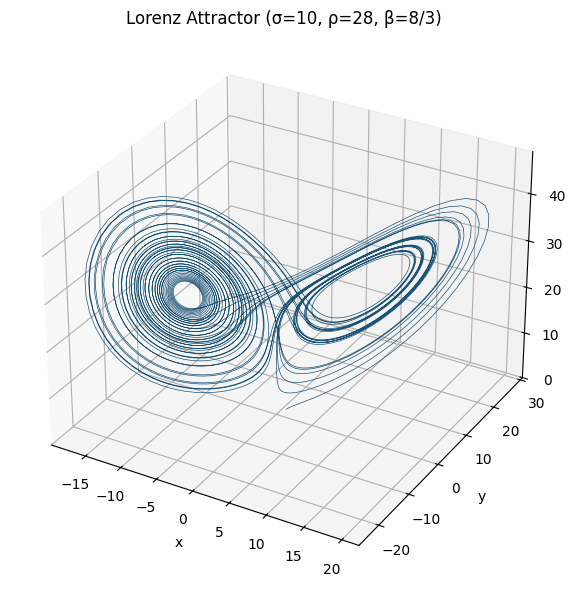

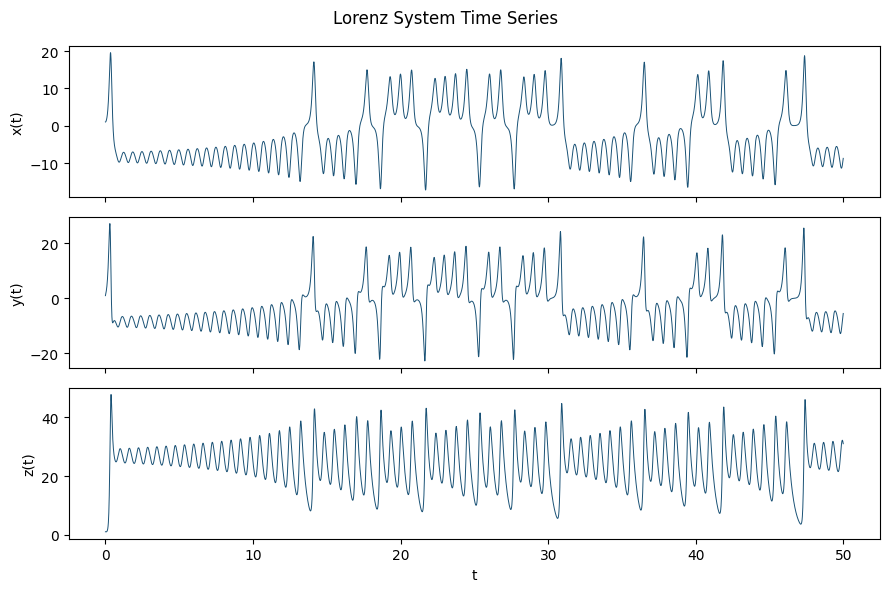

In [46]:
def lorenz(t, s, sigma=10, rho=28, beta=8/3):
    x, y, z = s
    return [sigma*(y-x), x*(rho-z)-y, x*y - beta*z]

t, y = integrate(lorenz, [1, 1, 1], (0, 50), 0.01)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
ax.plot(y[0], y[1], y[2], lw=0.5, color="#1a5276")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title("Lorenz Attractor (σ=10, ρ=28, β=8/3)")

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
for i, lbl in enumerate(["x(t)", "y(t)", "z(t)"]):
    axs[i].plot(t, y[i], lw=0.7, color="#1a5276")
    axs[i].set_ylabel(lbl)
axs[-1].set_xlabel("t")

fig.suptitle("Lorenz System Time Series")
plt.tight_layout()
plt.show()

lorenz_t, lorenz_y = t, y  # keep baseline for Part C

B.3 Rossler system

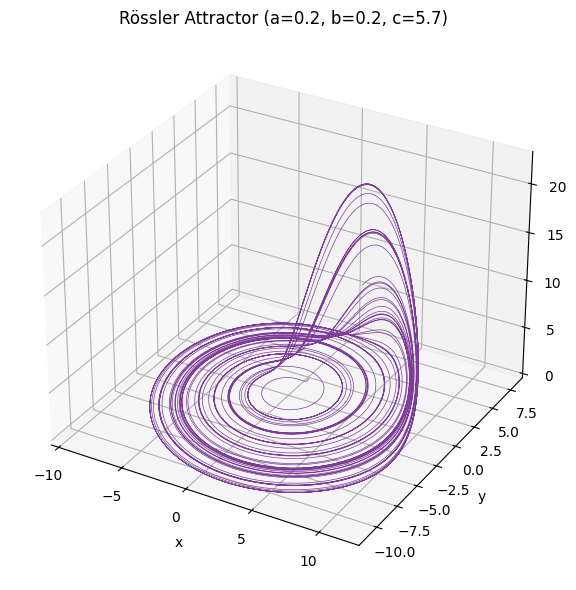

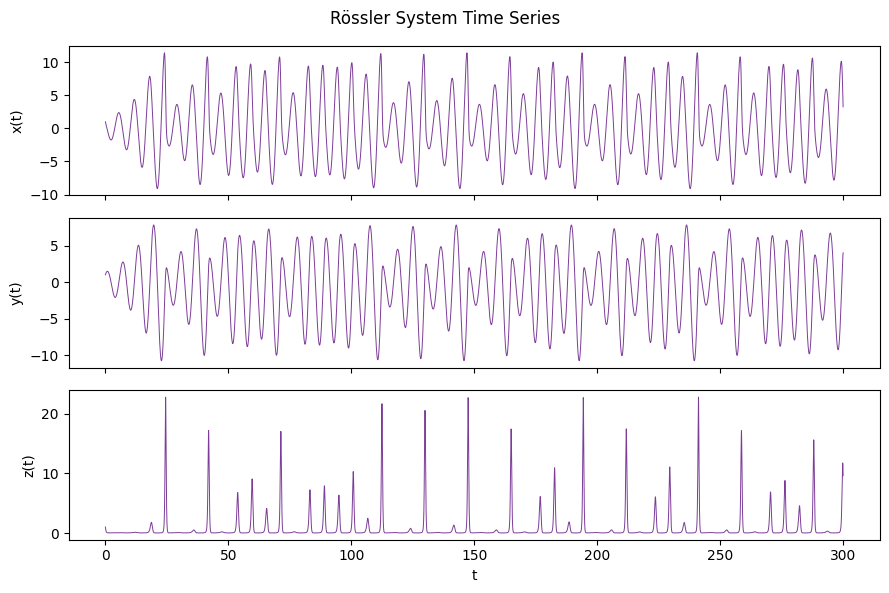

In [47]:
def rossler(t, s, a=0.2, b=0.2, c=5.7):
    x, y, z = s
    return [-y - z, x + a*y, b + z*(x - c)]

t, y = integrate(rossler, [1, 1, 1], (0, 300), 0.01)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
ax.plot(y[0], y[1], y[2], lw=0.5, color="#7d3c98")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title("Rössler Attractor (a=0.2, b=0.2, c=5.7)")

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
for i, lbl in enumerate(["x(t)", "y(t)", "z(t)"]):
    axs[i].plot(t, y[i], lw=0.7, color="#7d3c98")
    axs[i].set_ylabel(lbl)
axs[-1].set_xlabel("t")

fig.suptitle("Rössler System Time Series")
plt.tight_layout()
plt.show()

B.4 Chen system

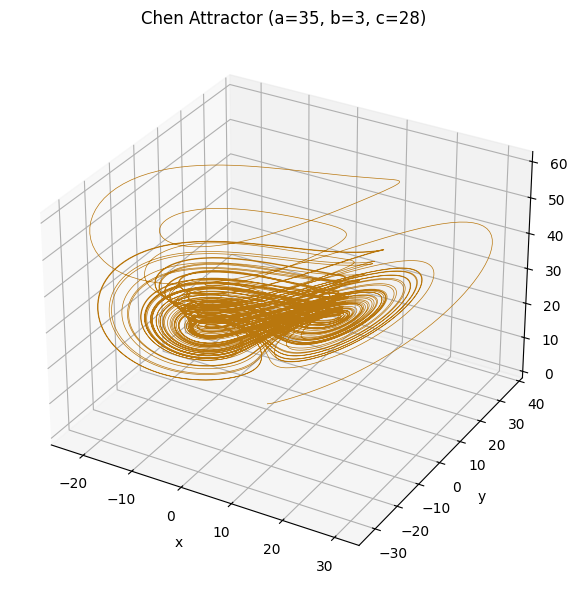

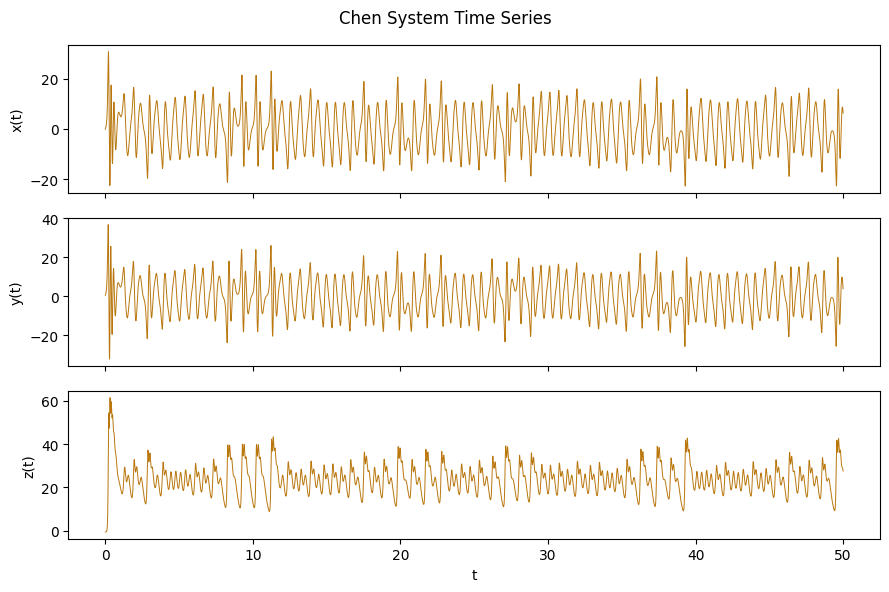

In [48]:
def chen(t, s, a=35, b=3, c=28):
    x, y, z = s
    return [a*(y - x), (c - a)*x - x*z + c*y, x*y - b*z]

t, y = integrate(chen, [-0.1, 0.5, -0.6], (0, 50), 0.002)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
ax.plot(y[0], y[1], y[2], lw=0.5, color="#b9770e")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title("Chen Attractor (a=35, b=3, c=28)")

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
for i, lbl in enumerate(["x(t)", "y(t)", "z(t)"]):
    axs[i].plot(t, y[i], lw=0.7, color="#b9770e")
    axs[i].set_ylabel(lbl)
axs[-1].set_xlabel("t")

fig.suptitle("Chen System Time Series")
plt.tight_layout()
plt.show()

B.5 Hyperchaotic Rossler (4D)

xdot = -y - z ; ydot = x + a*y + w ; zdot = b + xz ; wdot = -c*z + d*w

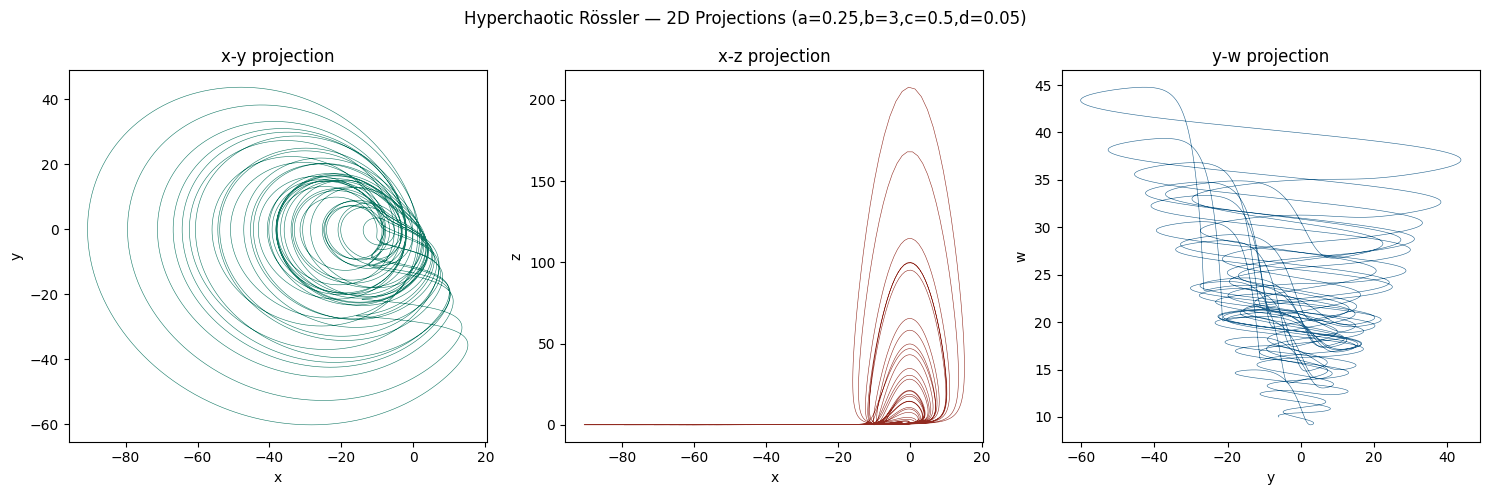

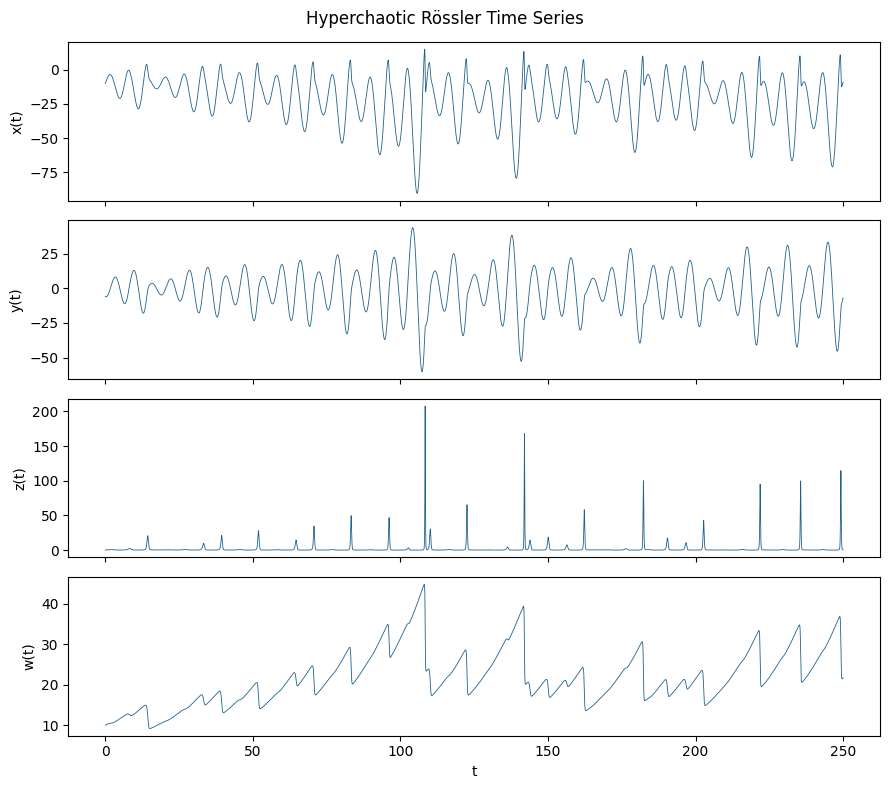

In [26]:
def hyper_rossler(t, s, a=0.25, b=3, c=0.5, d=0.05):
    x, y, z, w = s
    return [-y - z, x + a*y + w, b + x*z, -c*z + d*w]

t, y = integrate(hyper_rossler, [-10, -6, 0, 10], (0, 250), 0.01)
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
pairs = [(0, 1, "x", "y"), (0, 2, "x", "z"), (1, 3, "y", "w")]
colors = ["#117864", "#922b21", "#1f618d"]

for ax, (i, j, li, lj), col in zip(axs, pairs, colors):
    ax.plot(y[i], y[j], lw=0.4, color=col)
    ax.set_xlabel(li); ax.set_ylabel(lj)
    ax.set_title(f"{li}-{lj} projection")

fig.suptitle("Hyperchaotic Rössler — 2D Projections (a=0.25,b=3,c=0.5,d=0.05)")
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(4, 1, figsize=(9, 8), sharex=True)
for i, lbl in enumerate(["x(t)", "y(t)", "z(t)", "w(t)"]):
    axs[i].plot(t, y[i], lw=0.6, color="#1f618d")
    axs[i].set_ylabel(lbl)
axs[-1].set_xlabel("t")

fig.suptitle("Hyperchaotic Rössler Time Series")
plt.tight_layout()
plt.show()

# Part C - Sensitivity Analysis

In [27]:
def lorenz(t, s, sigma=10, rho=28, beta=8/3):
    x, y, z = s
    return [sigma*(y-x), x*(rho-z)-y, x*y - beta*z]

C.1 rho sweep

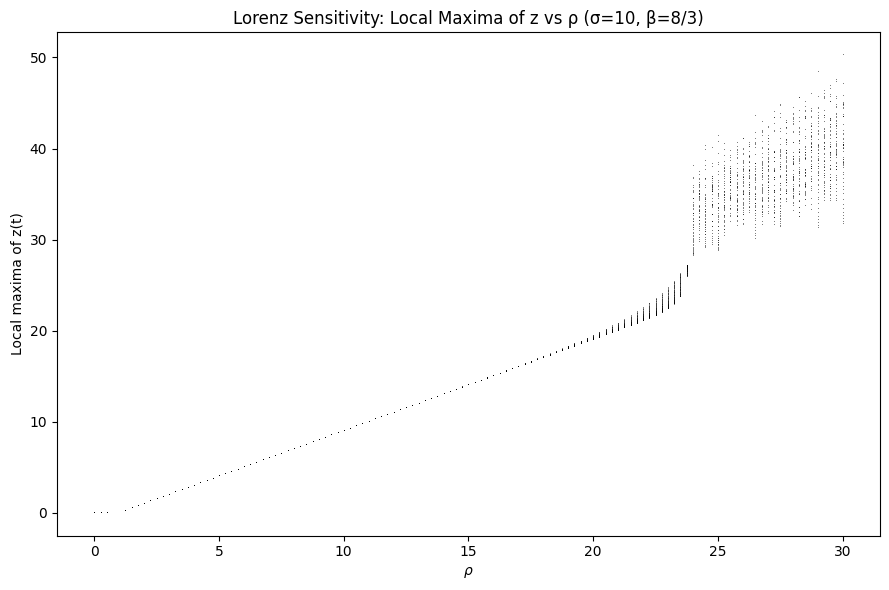

In [29]:
rho_vals = np.arange(0, 30.1, 0.25)
Rp, Zmax = [], []
dt = 0.01
T = 60
transient = 20

for rho in rho_vals:
    t_eval = np.arange(0, T, dt)
    sol = solve_ivp(lorenz, (0, T), [1, 1, 1], t_eval=t_eval, args=(10, rho, 8/3),
                     method="RK45", rtol=1e-8, atol=1e-8)
    mask = sol.t > transient
    z = sol.y[2][mask]
    maxima_idx = argrelextrema(z, np.greater)[0]

    for idx in maxima_idx:
        Rp.append(rho)
        Zmax.append(z[idx])

plt.figure(figsize=(9, 6))
plt.plot(Rp, Zmax, ',k', alpha=0.5, markersize=1)
plt.xlabel(r"$\rho$")
plt.ylabel("Local maxima of z(t)")
plt.title("Lorenz Sensitivity: Local Maxima of z vs ρ (σ=10, β=8/3)")
plt.tight_layout()
plt.show()

 C.2 step-size sensitivity

In [30]:
dts = [0.001, 0.01, 0.05]
labels = ["dt=0.001 (fine)", "dt=0.01 (baseline)", "dt=0.05 (coarse)"]
colors = ["#1a5276", "#c0392b", "#117864"]
T = 50
ic = [1, 1, 1]

results = {}
for dt_ in dts:
    t_eval = np.arange(0, T, dt_)
    sol = solve_ivp(lorenz, (0, T), ic, t_eval=t_eval, args=(10, 28, 8/3),
                     method="RK45", rtol=1e-10, atol=1e-10)
    results[dt_] = (sol.t, sol.y)

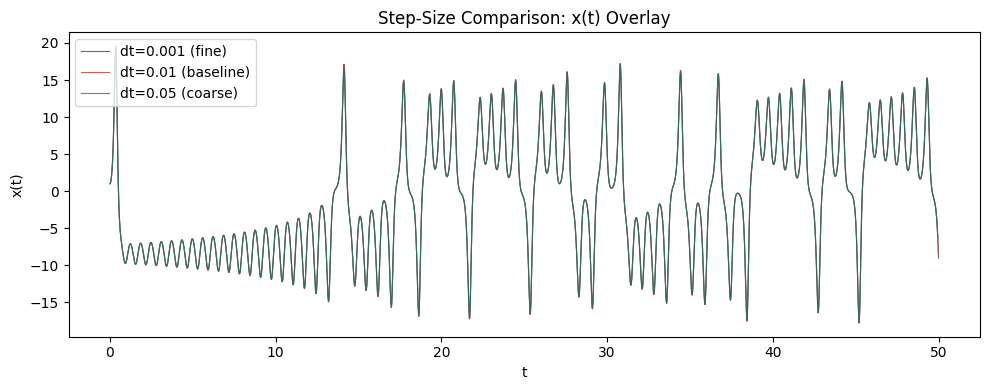

In [31]:
# (i) overlay x(t)
plt.figure(figsize=(10, 4))
for dt_, lbl, col in zip(dts, labels, colors):
    t_, y_ = results[dt_]
    plt.plot(t_, y_[0], lw=0.8, label=lbl, color=col, alpha=0.8)

plt.xlabel("t"); plt.ylabel("x(t)")
plt.title("Step-Size Comparison: x(t) Overlay")
plt.legend()
plt.tight_layout()
plt.show()

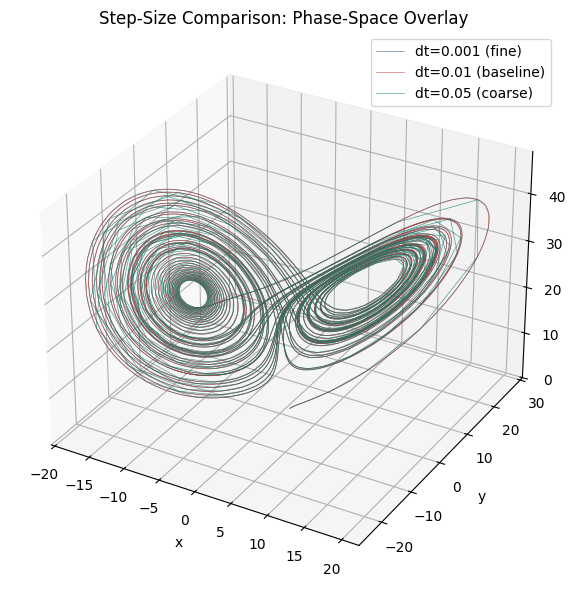

In [32]:
# (ii) overlay 3D phase trajectories
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")

for dt_, lbl, col in zip(dts, labels, colors):
    t_, y_ = results[dt_]
    ax.plot(y_[0], y_[1], y_[2], lw=0.5, label=lbl, color=col, alpha=0.7)

ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title("Step-Size Comparison: Phase-Space Overlay")
ax.legend()
plt.tight_layout()
plt.show()

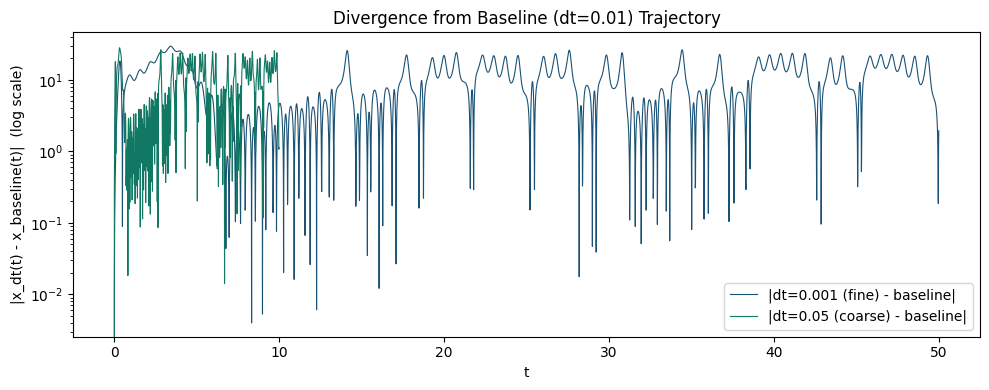

In [34]:
# (iii) pairwise divergence vs baseline (dt=0.01)
t_base, y_base = results[0.01]

plt.figure(figsize=(10, 4))
for dt_, lbl, col in zip([0.001, 0.05], [labels[0], labels[2]], [colors[0], colors[2]]):
    t_, y_ = results[dt_]
    n = min(len(t_base), len(t_))
    diff = np.abs(y_[0][:n] - y_base[0][:n])
    plt.semilogy(t_base[:n], diff, lw=0.8, label=f"|{lbl} - baseline|", color=col)

plt.xlabel("t"); plt.ylabel("|x_dt(t) - x_baseline(t)|  (log scale)")
plt.title("Divergence from Baseline (dt=0.01) Trajectory")
plt.legend()
plt.tight_layout()
plt.show()